In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Dataset folder
dataset_path = "/content/drive/MyDrive/ScreenDefectDataset"

# Prepare lists for paths and labels
all_image_paths = []
all_labels = []

# Iterate through files to create paths and labels consistently
for filename in os.listdir(dataset_path):
    path = os.path.join(dataset_path, filename)
    if os.path.isfile(path): # Ensure it's a file, not a subdirectory
        if "_ok_" in filename:
            all_image_paths.append(path)
            all_labels.append(0)  # normal
        elif "_ng_" in filename:
            all_image_paths.append(path)
            all_labels.append(1)  # defect

image_paths = all_image_paths
labels = np.array(all_labels)

print(f"Found {len(image_paths)} images and {len(labels)} corresponding labels.")

Found 2480 images and 2480 corresponding labels.


In [5]:
# Train / Validation split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42
)

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# Image loader function
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

# Create datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(lambda x,y: load_image(x,y)).batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(lambda x,y: load_image(x,y)).batch(BATCH_SIZE)

In [6]:
# Data augmentation
data_aug = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomBrightness(0.2)
])

# MobileNetV2 model
base_model = MobileNetV2(input_shape=(224,224,3),
                         include_top=False,
                         weights="imagenet")

base_model.trainable = False

model = models.Sequential([
    data_aug,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# Train
model.fit(train_ds, validation_data=val_ds, epochs=10)

# Fine tuning
base_model.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.8775 - loss: 0.4104 - val_accuracy: 0.9093 - val_loss: 0.2813
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.9052 - loss: 0.3308 - val_accuracy: 0.9093 - val_loss: 0.3014
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.9032 - loss: 0.3420 - val_accuracy: 0.9093 - val_loss: 0.2905
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9057 - loss: 0.3375 - val_accuracy: 0.9093 - val_loss: 0.2766
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.9068 - loss: 0.3412 - val_accuracy: 0.9093 - val_loss: 0.2826
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9068 - loss: 0.3303 - val_accuracy: 0.9093 - val_loss: 0.2786
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.9068 - loss: 0.3447 - val_accuracy: 0.9093 - val_loss: 0.3272
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 0.9068 - loss: 0.3373 - val_accuracy: 0.9093 - v

In [8]:
# Evaluation
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)


16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9093 - loss: 0.2935
Accuracy: 0.9092742204666138


In [9]:
# Predictions
y_true = val_labels
y_pred = np.argmax(model.predict(val_ds), axis=1)

print(classification_report(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        45
           1       0.91      1.00      0.95       451

    accuracy                           0.91       496
   macro avg       0.45      0.50      0.48       496
weighted avg       0.83      0.91      0.87       496



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


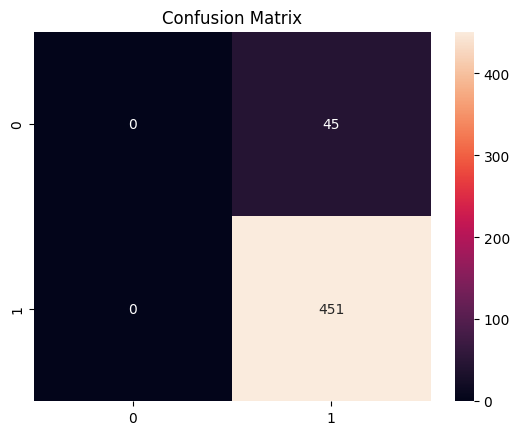

In [10]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()